# Fine-tune process

To do:

(1) Change the loss function (fine-tuning) to exclude basin_std for fine-tuning one single basin. Now, I laod scaler obtained from pre-training for fine-tuning, val, and test dataset. I also calculate basin_std and use "Basin-averaged NSE" in loss function, if we fine-tune on over one basin. 



In [1]:
# Import necessary packages
import datetime
import pickle
import random
import sys
import time

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.append("..")
# Import classes and functions from other files
from hy2dl.datasetzoo import get_dataset
from hy2dl.evaluation.metrics import forecast_NSE, forecast_PNSE
from hy2dl.modelzoo import get_model
from hy2dl.training.loss import nse_basin_averaged
from hy2dl.utils.config import Config
from hy2dl.utils.optimizer import Optimizer
from hy2dl.utils.utils import set_random_seed, upload_to_device

# colorblind friendly palette
color_palette = {"observed": "#377eb8", "simulated": "#4daf4a"}

## Load model config

It loads a pre-trained model's config as the base config, then it updates the config for fine-tuning, including: pre_trained_path, finetune_modules, etc.

In [ ]:
# load finetune config and check for a non-empty list of finetune_modules
fine_tune_config_file = "../examples/finetune_de_forecast.yml"

temp_config = Config(fine_tune_config_file)
if not temp_config.finetune_modules:
    raise ValueError("For finetuning, at least one model part has to be specified by 'finetune_modules'.")

# extract pre_trained_path, load base run config and combine with the finetune arguments
config = Config(temp_config.pre_trained_path / "config.yml")
# config.update_config({'run_dir': None, 'experiment_name': None})
config.update_config(fine_tune_config_file)
config.is_finetuning = True

config.init_experiment()
config.dump()
set_random_seed(cfg=config)

## Load train_loader

In [ ]:
# Get dataset class
Dataset = get_dataset(config)

# Dataset training
config.logger.info(f"Loading training data from {config.dataset} dataset")
total_time = time.time()

training_dataset = Dataset(cfg=config, time_period="training")

load_pretrained_scaler = False  # To do: add it in config.py

# perform standardization on fine-tuning data using the values from pre-training process
# here, I also calculate basin_std, if we fine-tune on over one basin,
#  and use "Basin-averaged NSE" in loss function
if load_pretrained_scaler:
    scaler_path = config.pre_trained_path / "scaler.pickle"
    with open(scaler_path, "rb") as f:
        pretrained_scaler = pickle.load(f)
    config.logger.info(f"Standardize fine-tuning data using scaler obtaied from pre-training process: {scaler_path}")
    training_dataset.calculate_basin_std()
    training_dataset.scaler = pretrained_scaler
    training_dataset.standardize_data()
# perform standardization on fine-tuning data using values calculated from this data
else:
    config.logger.info(f"Standardize fine-tuning data without scaler obtaied from pre-training process")
    training_dataset.calculate_basin_std()
    training_dataset.calculate_global_statistics(save_scaler=True)
    training_dataset.standardize_data()

config.logger.info(f"Number of entities with valid samples: {len(training_dataset.df_ts)}")
config.logger.info(
    f"Time required to process {len(training_dataset.df_ts)} entities: "
    f"{datetime.timedelta(seconds=int(time.time() - total_time))}"
)
config.logger.info(f"Number of valid training samples: {len(training_dataset)}\n")

# Dataloader training
train_loader = DataLoader(
    dataset=training_dataset,
    batch_size=config.batch_size_training,
    shuffle=True,
    drop_last=True,
    collate_fn=training_dataset.collate_fn,
    num_workers=config.num_workers,
)

# Print details of a loader´s sample to check that the format is correct
config.logger.info("Details training dataloader".center(60, "-"))
config.logger.info(f"Batch structure (number of batches: {len(train_loader)})")
config.logger.info(f"{'Key':^30}|{'Shape':^30}")
# config.logger.info("-" * 60)
# Loop through the sample dictionary and print the shape of each element
for key, value in next(iter(train_loader)).items():
    if key.startswith(("x_d", "x_conceptual")):
        config.logger.info(f"{key}")
        for i, v in value.items():
            config.logger.info(f"{i:^30}|{str(v.shape):^30}")
    else:
        config.logger.info(f"{key:<30}|{str(value.shape):^30}")

config.logger.info("")  # prints a blank line

2025-11-30 16:10:41 - Loading training data from hourly_camels_de dataset
2025-11-30 16:10:49 - Standardize fine-tuning data without scaler obtaied from pre-training process
2025-11-30 16:10:49 - Number of entities with valid samples: 1
2025-11-30 16:10:49 - Time required to process 1 entities: 0:00:07
2025-11-30 16:10:49 - Number of valid training samples: 119329

2025-11-30 16:10:49 - ----------------Details training dataloader-----------------
2025-11-30 16:10:49 - Batch structure (number of batches: 466)
2025-11-30 16:10:49 -              Key              |            Shape             


/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/src/hy2dl/datasetzoo/basedataset.py:395: UserWarning: The standard deviation of area is NaN or zero. The std has been forced to 1 to avoid NaN issues during normalization.
  self.scaler["x_s_std"] = torch.tensor(list(self._check_std(x_s_std).values()), dtype=torch.float32)
/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/src/hy2dl/datasetzoo/basedataset.py:395: UserWarning: The standard deviation of elev_mean is NaN or zero. The std has been forced to 1 to avoid NaN issues during normalization.
  self.scaler["x_s_std"] = torch.tensor(list(self._check_std(x_s_std).values()), dtype=torch.float32)
/hkfs/home/haicore/iwu/qa8171/Project/Hy2DL/src/hy2dl/datasetzoo/basedataset.py:395: UserWarning: The standard deviation of clay_0_30cm_mean is NaN or zero. The std has been forced to 1 to avoid NaN issues during normalization.
  self.scaler["x_s_std"] = torch.tensor(list(self._check_std(x_s_std).values()), dtype=torch.float32)
/hkfs/home/haicore/iwu/qa8171

2025-11-30 16:10:49 - x_d_1W
2025-11-30 16:10:49 -    precipitation_resampled    |    torch.Size([256, 24])     
2025-11-30 16:10:49 -   air_temperature_mean_mean   |    torch.Size([256, 24])     
2025-11-30 16:10:49 - global_shortwave_radiation_mean|    torch.Size([256, 24])     
2025-11-30 16:10:49 -     relative_humidity_mean    |    torch.Size([256, 24])     
2025-11-30 16:10:49 -        wind_speed_mean        |    torch.Size([256, 24])     
2025-11-30 16:10:49 - x_d_1D
2025-11-30 16:10:49 -    precipitation_resampled    |    torch.Size([256, 193])    
2025-11-30 16:10:49 -   air_temperature_mean_mean   |    torch.Size([256, 193])    
2025-11-30 16:10:49 - global_shortwave_radiation_mean|    torch.Size([256, 193])    
2025-11-30 16:10:49 -     relative_humidity_mean    |    torch.Size([256, 193])    
2025-11-30 16:10:49 -        wind_speed_mean        |    torch.Size([256, 193])    
2025-11-30 16:10:49 - x_d_1h
2025-11-30 16:10:49 -     precipitation_sum_mean    |    torch.Size([25

## Load val dataset

In [4]:
# In evaluation (validation and testing) we will create an individual dataset per basin
config.logger.info(f"Loading validation data from {config.dataset} dataset")
entities_ids = np.loadtxt(config.path_entities_validation, dtype="str").tolist()
iterator = tqdm(
    [entities_ids] if isinstance(entities_ids, str) else entities_ids,
    desc="Processing entities",
    unit="entity",
    ascii=True,
)

total_time = time.time()
validation_dataset = {}
for entity in iterator:
    dataset = Dataset(cfg=config, time_period="validation", check_NaN=False, entities_ids=entity)
    dataset.scaler = training_dataset.scaler
    dataset.standardize_data(standardize_output=False)
    validation_dataset[entity] = dataset

config.logger.info(
    f"Time required to process {len(iterator)} entities: {datetime.timedelta(seconds=int(time.time() - total_time))}\n"
)

2025-11-30 16:10:49 - Loading validation data from hourly_camels_de dataset


Processing entities: 100%|##########| 1/1 [00:04<00:00,  4.42s/entity]

2025-11-30 16:10:54 - Time required to process 1 entities: 0:00:04



## Load pre-trained model weights

In [5]:
# Initialize model
model = get_model(config).to(config.device)

# Load pre-trained model from a checkpoint file
checkpoint_path = "../results/bs_256_uniqueBlocksFalse_random_1_seed_110/model/model_epoch_12"
state = torch.load(checkpoint_path, map_location=config.device)
model.load_state_dict(state)
config.logger.info(f"Starting training from checkpoint {checkpoint_path}")

# config.logger.info(f"Model layers: {state.keys()}")
# config.logger.info(f"Model architecture: {model}")

2025-11-30 16:11:12 - Starting training from checkpoint ../results/bs_256_uniqueBlocksFalse_random_1_seed_110/model/model_epoch_12


## Freeze model's modules (if needed)

In [6]:
# freeze all model weights
for param in model.parameters():
    param.requires_grad = False

unresolved_modules = []

# unfreeze parameters specified in config as tuneable parameters
if isinstance(config.finetune_modules, list):
    for module_part in config.finetune_modules:
        if module_part in model.module_parts:
            module = getattr(model, module_part)
            config.logger.info(f"Trainable modules: {module}")
            for param in module.parameters():
                param.requires_grad = True
        else:
            unresolved_modules.append(module_part)
else:
    # if it was no list, it has to be a dictionary
    for module_group, module_parts in config.finetune_modules.items():
        if module_group in model.module_parts:
            if isinstance(module_parts, str):
                module_parts = [module_parts]
            for module_part in module_parts:
                module = getattr(model, module_group)[module_part]
                config.logger.info(f"Trainable modules: {module}")
                for param in module.parameters():
                    param.requires_grad = True
            else:
                unresolved_modules.append(module_group)
if unresolved_modules:
    config.logger.warning(f"Could not resolve the following module parts for finetuning: {unresolved_modules}")

2025-11-30 16:11:15 - Trainable modules: InputLayer(
  (emb_x_d): ModuleDict(
    (x_d_1W): Sequential(
      (0): Linear(in_features=5, out_features=10, bias=True)
      (1): ReLU()
      (2): Linear(in_features=10, out_features=10, bias=True)
      (3): ReLU()
      (4): Linear(in_features=10, out_features=10, bias=True)
    )
    (x_d_1D): Sequential(
      (0): Linear(in_features=5, out_features=10, bias=True)
      (1): ReLU()
      (2): Linear(in_features=10, out_features=10, bias=True)
      (3): ReLU()
      (4): Linear(in_features=10, out_features=10, bias=True)
    )
    (x_d_1h): Sequential(
      (0): Linear(in_features=5, out_features=10, bias=True)
      (1): ReLU()
      (2): Linear(in_features=10, out_features=10, bias=True)
      (3): ReLU()
      (4): Linear(in_features=10, out_features=10, bias=True)
    )
  )
  (emb_x_s): Identity()
)
2025-11-30 16:11:15 - Trainable modules: InputLayer(
  (emb_x_d): ModuleDict(
    (x_d_fc): Sequential(
      (0): Linear(in_features

## Fine-tune model

In [ ]:
# Initialize optimizer
optimizer = Optimizer(cfg=config, model=model)

# Training report structure
config.logger.info("Training model".center(60, "-"))
config.logger.info(f"{'':^16}|{'Trainining':^21}|{'Validation':^21}|")
config.logger.info(f"{'Epoch':^5}|{'LR':^10}|{'Loss':^10}|{'Time':^10}|{'Metric':^10}|{'Time':^10}|")

total_time = time.time()
# Loop through epochs`
for epoch in range(1, config.epochs + 1):
    train_time = time.time()
    loss_evol = []
    # Training -------------------------------------------------------------------------------------------------------
    model.train()
    # Loop through the different batches in the training dataset
    iterator = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{config.epochs}. Training",
        unit="batches",
        ascii=True,
        leave=False,
    )

    for idx, sample in enumerate(iterator):
        # reach maximum iterations per epoch
        if config.max_updates_per_epoch is not None and idx >= config.max_updates_per_epoch:
            break

        sample = upload_to_device(sample, config.device)  # upload tensors to device
        optimizer.optimizer.zero_grad()  # sets gradients to zero

        # Forward pass of the model
        pred = model(sample)
        # Calcuate loss
        loss = nse_basin_averaged(y_sim=pred["y_hat"], y_obs=sample["y_obs"], per_basin_target_std=sample["std_basin"])

        # Backpropagation (calculate gradients)
        loss.backward()

        # Update model parameters (e.g, weights and biases)
        optimizer.clip_grad_and_step(epoch, idx)

        # Keep track of the loss per batch
        loss_evol.append(loss.item())
        iterator.set_postfix({"average loss": f"{np.mean(loss_evol):.3f}"})

        # remove elements from cuda to free memory
        del sample, pred
        torch.cuda.empty_cache()

    # training report
    lr = optimizer.optimizer.param_groups[0]["lr"]
    mean_loss = np.mean(loss_evol)
    train_duration = str(datetime.timedelta(seconds=int(time.time() - train_time)))
    report = f"{epoch:^5}|{lr:^10.5f}|{mean_loss:^10.3f}|{train_duration:^10}|"

    # Validation -----------------------------------------------------------------------------------------------------
    if epoch % config.validate_every == 0:
        val_time = time.time()
        model.eval()
        validation_results = {}
        with torch.no_grad():
            # If we define validate_n_random_basins as 0 or negative, we take all the basins. Otherwise, we randomly 
            # select the number of basins defined in validate_n_random_basins
            if config.validate_n_random_basins <= 0:
                validation_basin_ids = validation_dataset.keys()
            else:
                validation_basin_ids = random.sample(list(validation_dataset.keys()), config.validate_n_random_basins)

            # Go through each basin
            iterator = tqdm(
                validation_basin_ids,
                desc=f"Epoch {epoch}/{config.epochs}. Validation",
                unit="basins",
                ascii=True,
                leave=False,
            )

            for basin in iterator:
                loader = DataLoader(
                    dataset=validation_dataset[basin],
                    batch_size=config.batch_size_evaluation,
                    shuffle=False,
                    drop_last=False,
                    collate_fn=validation_dataset[basin].collate_fn,
                    num_workers=config.num_workers,
                )

                dates, observed_values, simulated_values = [], [], []
                for i, sample in enumerate(loader):
                    sample = upload_to_device(sample, config.device)  # upload tensors to device
                    pred = model(sample)
                    # backtransformed information
                    y_sim = (
                        pred["y_hat"] * validation_dataset[basin].scaler["y_std"].to(config.device)
                    )
                    y_mean = validation_dataset[basin].scaler["y_mean"].to(config.device)
                    y_sim = y_sim + y_mean

                    # Join the results from the different batches
                    dates.extend(sample["date_issue_fc"])
                    observed_values.extend(sample["persistent_q"].cpu().detach().numpy())
                    simulated_values.append(y_sim.cpu().detach().numpy())
                    if i == len(loader) - 1:
                        dates.extend(sample["date"][-1, :])
                        observed_values.extend(sample["y_obs"][-1, :].cpu().detach().numpy())

                    # remove from cuda
                    del sample, pred, y_sim
                    torch.cuda.empty_cache()

                # Construct dataframe with observed and simulated values
                df = pd.DataFrame(index=dates)
                df["Observed"] = np.concatenate(observed_values, axis=0)
                y_sim = np.squeeze(np.concatenate(simulated_values, axis=0), -1)
                y_sim = np.concatenate((y_sim, np.full([y_sim.shape[1], y_sim.shape[1]], np.nan)), axis=0)
                df[[f"lead_time_{i + 1}" for i in range(y_sim.shape[1])]] = y_sim

                validation_results[basin] = df

            # average loss validation
            loss_validation = forecast_NSE(results=validation_results).median().mean()
            report += f"{loss_validation:^10.3f}|{str(datetime.timedelta(seconds=int(time.time() - val_time))):^10}|"

    # No validation
    else:
        report += f"{'':^10}|{'':^10}|"

    # Print report and save model
    config.logger.info(report)
    torch.save(model.state_dict(), config.path_save_folder / "model" / f"model_epoch_{epoch}")
    # modify learning rate
    optimizer.update_optimizer_lr(epoch=epoch)

# print total training time
config.logger.info(f"Total training time: {datetime.timedelta(seconds=int(time.time() - total_time))}\n")

2025-11-30 16:11:18 - -----------------------Training model-----------------------
2025-11-30 16:11:18 -                 |     Trainining      |     Validation      |
2025-11-30 16:11:18 - Epoch|    LR    |   Loss   |   Time   |  Metric  |   Time   |


Epoch 1/6. Training:   0%|          | 0/466 [00:00<?, ?batches/s]/hkfs/home/haicore/iwu/qa8171/env/HY3.11/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                                                                

2025-11-30 16:12:15 -   1  | 0.00010  |  6.803   | 0:00:48  |  0.894   | 0:00:08  |


Epoch 2/6. Training:   0%|          | 0/466 [00:00<?, ?batches/s]/hkfs/home/haicore/iwu/qa8171/env/HY3.11/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                                                               

2025-11-30 16:13:12 -   2  | 0.00010  |  1.620   | 0:00:48  |  0.900   | 0:00:08  |


Epoch 3/6. Training:   0%|          | 0/466 [00:00<?, ?batches/s]/hkfs/home/haicore/iwu/qa8171/env/HY3.11/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                                                               

2025-11-30 16:14:09 -   3  | 0.00010  |  1.172   | 0:00:48  |  0.905   | 0:00:08  |


Epoch 4/6. Training:   0%|          | 0/466 [00:00<?, ?batches/s]/hkfs/home/haicore/iwu/qa8171/env/HY3.11/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 4/6. Training:  10%|#         | 47/466 [00:05<00:49,  8.43batches/s, average loss=1.039]

## Test model

In [ ]:
# # Read previously generated scaler
# with open(config.path_save_folder / "scaler.pickle", "rb") as file:
#     scaler = pickle.load(file)

In [9]:
# In evaluation (validation and testing) we will create an individual dataset per basin
config.logger.info(f"Loading testing data from {config.dataset} dataset")

entities_ids = np.loadtxt(config.path_entities_testing, dtype="str").tolist()
iterator = tqdm(
    [entities_ids] if isinstance(entities_ids, str) else entities_ids,
    desc="Processing entities",
    unit="entity",
    ascii=True,
)

total_time = time.time()
testing_dataset = {}
for entity in iterator:
    dataset = Dataset(cfg=config, time_period="testing", check_NaN=False, entities_ids=entity)
    # Load the training scaler
    dataset.scaler = training_dataset.scaler
    dataset.standardize_data(standardize_output=False)
    testing_dataset[entity] = dataset

config.logger.info(
    f"Time required to process {len(iterator)} entities: {datetime.timedelta(seconds=int(time.time() - total_time))}\n"
)

2025-11-30 16:07:57 - Loading testing data from hourly_camels_de dataset


Processing entities: 100%|##########| 1/1 [00:04<00:00,  4.43s/entity]

2025-11-30 16:08:01 - Time required to process 1 entities: 0:00:04



In [10]:
config.logger.info("Testing model".center(60, "-"))
total_time = time.time()

model.eval()
test_results = {}
with torch.no_grad():
    # Go through each basin
    iterator = tqdm(testing_dataset, desc="Testing", unit="basins", ascii=True)
    for basin in iterator:
        loader = DataLoader(
            dataset=testing_dataset[basin],
            batch_size=config.batch_size_evaluation,
            shuffle=False,
            drop_last=False,
            collate_fn=testing_dataset[basin].collate_fn,
            num_workers=config.num_workers,
        )

        dates, simulated_values, observed_values = [], [], []
        for i, sample in enumerate(loader):
            sample = upload_to_device(sample, config.device)  # upload tensors to device
            pred = model(sample)
            # backtransformed information
            y_sim = pred["y_hat"] * testing_dataset[basin].scaler["y_std"].to(config.device) + testing_dataset[
                basin
            ].scaler["y_mean"].to(config.device)

            # Join the results from the different batches
            dates.extend(sample["date_issue_fc"])
            observed_values.extend(sample["persistent_q"].cpu().detach().numpy())
            simulated_values.append(y_sim.cpu().detach().numpy())
            if i == len(loader) - 1:
                dates.extend(sample["date"][-1, :])
                observed_values.extend(sample["y_obs"][-1, :].cpu().detach().numpy())

            # remove from cuda
            del sample, pred, y_sim
            torch.cuda.empty_cache()

        # Construct dataframe with observed and simulated values
        df = pd.DataFrame(index=dates)
        df["Observed"] = np.concatenate(observed_values, axis=0)
        y_sim = np.squeeze(np.concatenate(simulated_values, axis=0), -1)
        y_sim = np.concatenate((y_sim, np.full([y_sim.shape[1], y_sim.shape[1]], np.nan)), axis=0)
        df[[f"lead_time_{i + 1}" for i in range(y_sim.shape[1])]] = y_sim

        # Save the dataframe in a basin-indexed dictionary
        test_results[basin] = df

# Save results as a pickle file
with open(config.path_save_folder / "test_results.pickle", "wb") as f:
    pickle.dump(test_results, f)

config.logger.info(f"Total testing time: {datetime.timedelta(seconds=int(time.time() - total_time))}")

2025-11-30 16:08:05 - -----------------------Testing model------------------------


Testing:   0%|          | 0/1 [00:00<?, ?basins/s]/hkfs/home/haicore/iwu/qa8171/env/HY3.11/lib64/python3.11/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing: 100%|##########| 1/1 [00:14<00:00, 14.03s/basins]

2025-11-30 16:08:19 - Total testing time: 0:00:14


## Initial analysis

2025-11-30 16:08:24 - The avearge of 'median forecast_NSE' across all lead times: 0.911
2025-11-30 16:08:24 - The avearge of 'median PNSE_NSE' across all lead times: -4.327


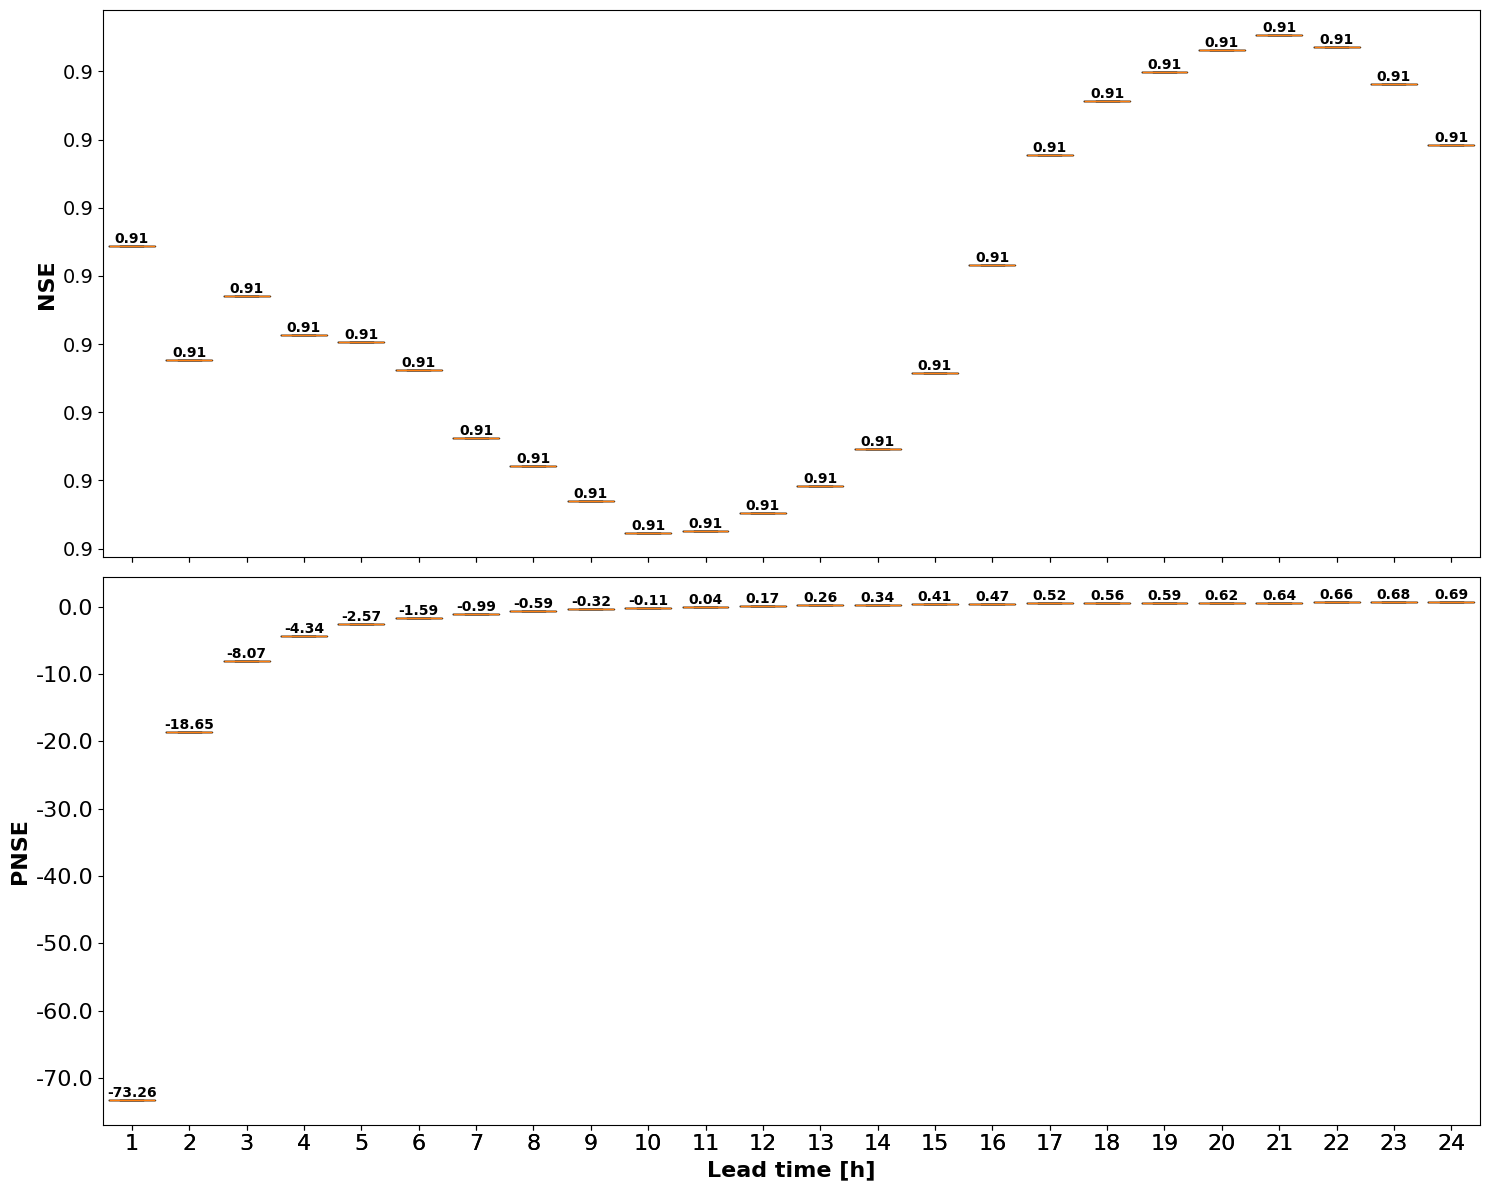

In [11]:
df_NSE = forecast_NSE(results=test_results)
df_PNSE = forecast_PNSE(results=test_results)

# Calculate the median forecast_NSE across all basins for each lead time
# Then, output the average value across all lead times
config.logger.info("The avearge of 'median forecast_NSE' across all lead times: %s", f"{df_NSE.median().mean():.3f}")
config.logger.info("The avearge of 'median PNSE_NSE' across all lead times: %s", f"{df_PNSE.median().mean():.3f}")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharex=True)  # Share x-axis

# First subplot: NSE
axes[0].boxplot(
    df_NSE.dropna().values,
    widths=0.8,
    positions=np.arange(len(df_NSE.columns)) + 1,
    showfliers=False,
)

medians = df_NSE.median(axis=0).values
for i, median in enumerate(medians):
    axes[0].text(
        i + 1,
        median,
        f"{median:.2f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

axes[0].set_ylabel("NSE", fontsize=16, fontweight="bold")
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
axes[0].tick_params(axis="both", labelsize=14)

# Second subplot: Boxplot
axes[1].boxplot(
    df_PNSE.dropna().values,
    widths=0.8,
    positions=np.arange(len(df_PNSE.columns)) + 1,
    showfliers=False,
)

# Add median values as text
medians = df_PNSE.median(axis=0).values
for i, median in enumerate(medians):
    axes[1].text(
        i + 1,
        median,
        f"{median:.2f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

axes[1].set_xlabel("Lead time [h]", fontsize=16, fontweight="bold")
axes[1].set_ylabel("PNSE", fontsize=16, fontweight="bold")
axes[1].tick_params(axis="both", labelsize=16)
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

# Adjust layout
plt.tight_layout()
plt.savefig(config.path_save_folder / "Test_NSE_PNSE_boxplot.jpg")
plt.show()

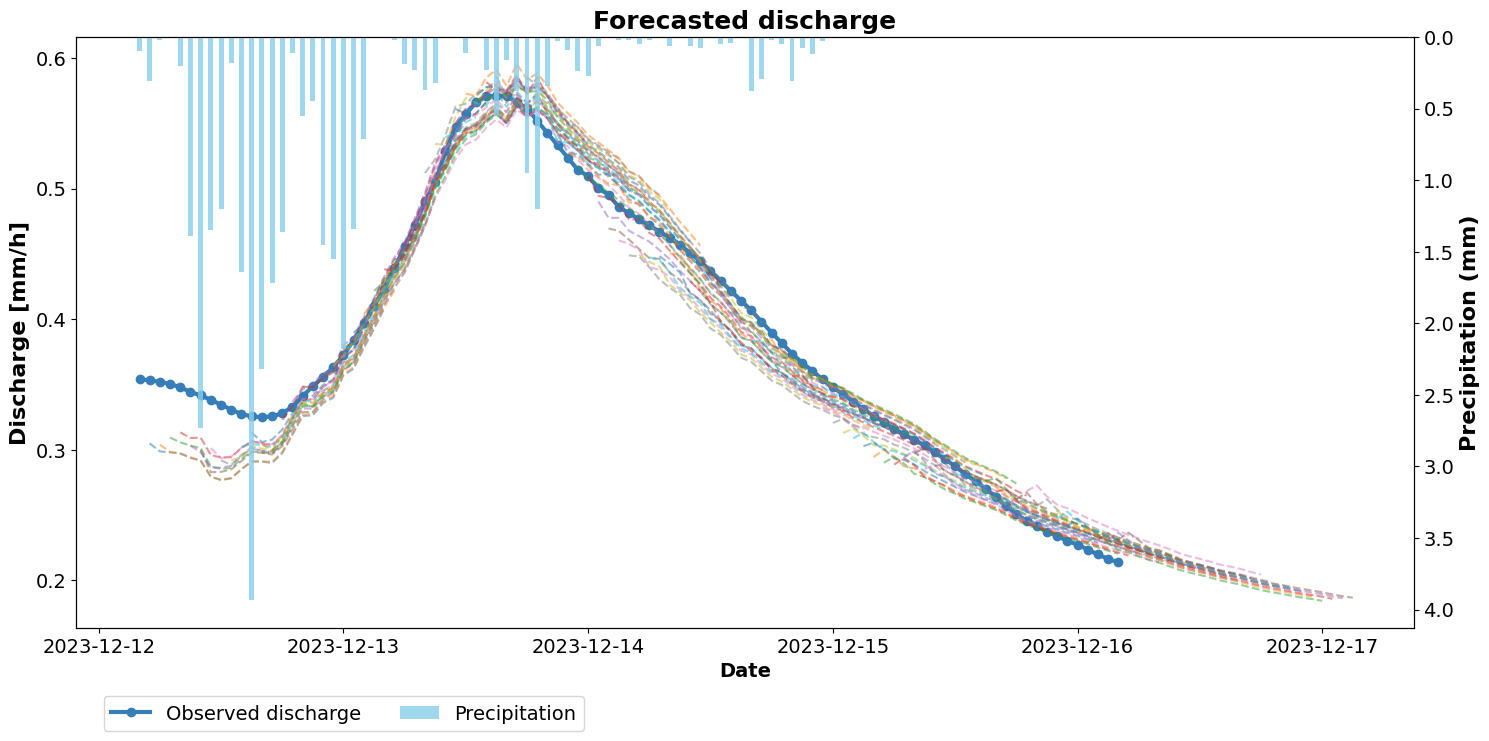

In [12]:
# Plot random basin and date
basin_to_analyze = random.sample(list(test_results.keys()), 1)[0]

# Establish period of interest as 48 hours before and after a random peak
date = random.sample(list(test_results[basin_to_analyze].Observed.nlargest(200).index), 1)[0]  # select one of the max 200 peaks
window_size = 48
start_date = date - pd.Timedelta(hours=window_size)
end_date = date + pd.Timedelta(hours=window_size)
period_of_interest = [start_date, end_date]

# Filter the results
df_period_of_interest = test_results[basin_to_analyze].loc[period_of_interest[0] : period_of_interest[1], :]

# Precipitation
df_prec = (
    testing_dataset[basin_to_analyze]
    .df_ts[basin_to_analyze]
    .loc[period_of_interest[0] : period_of_interest[1], ["precipitation_sum_mean"]]
)

# Create figure
fig, ax1 = plt.subplots(figsize=(15, 7.5))

# Observe series
ax1.plot(
    df_period_of_interest["Observed"],
    label="Observed discharge",
    color=color_palette["observed"],
    linewidth=3,
    marker="o",
)

# Simulated forecasted series
for i in range(df_period_of_interest.shape[0] - 1):
    time_slide = pd.date_range(
        start=df_period_of_interest.index[i + 1], periods=df_period_of_interest.shape[1] - 1, freq="h"
    )

    forecast = df_period_of_interest.iloc[i, 1:].values
    ax1.plot(time_slide, forecast, alpha=0.5, linestyle="--")

# Precipitation
ax2 = ax1.twinx()
ax2.bar(df_prec.index, df_prec.squeeze().values, color="skyblue", width=0.02, label="Precipitation", alpha=0.8)

# Format plot
ax1.set_xlabel("Date", fontsize=14, fontweight="bold")
ax1.tick_params(axis="x", labelsize=14)
ax1.set_ylabel("Discharge [mm/h]", fontsize=16, fontweight="bold")
ax1.tick_params(axis="y", labelsize=14)
ax1.set_title("Forecasted discharge", fontsize=18, fontweight="bold")

ax2.set_ylabel("Precipitation (mm)", fontsize=16, fontweight="bold")
ax2.tick_params(axis="both", which="major", labelsize=14)
ax2.invert_yaxis()

# Create legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center", bbox_to_anchor=(0.2, -0.1), ncol=5, fontsize=14)

plt.tight_layout()
plt.savefig(config.path_save_folder / "Forecasted_discharge.jpg")
plt.show()